## 1. Setup

In [1]:
# Setup de Google Colab (deshabilitado para ejecucion local)
# Si se ejecuta en Colab, descomentar las siguientes lineas:
# !git clone https://github.com/igcondor/SCY1101_Analisis_Semestral_2026.git
# %cd /content/SCY1101_Analisis_Semestral_2026
# !git checkout main
# !git pull

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_squared_error, r2_score,
                             confusion_matrix, ConfusionMatrixDisplay)

import sys
sys.path.append('.')
from src.preprocesamiento_data import preprocesar, pipeline_clasificacion, pipeline_regresion
from src.model_training import entrenar_clasificacion, entrenar_regresion
from src.model_evaluation import (evaluar_clasificacion_cv, evaluar_regresion_cv,
                                   tabla_comparacion_clf, tabla_comparacion_reg)

SEED = 42

## 2. Carga y Preparacion de Datos

Usamos el mismo pipeline de limpieza de los notebooks anteriores para garantizar que estamos trabajando con el mismo dataset.

In [3]:
df = preprocesar('retail_store_sales.csv')
print(f"Filas despues de limpieza: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas despues de limpieza: 7983
Columnas: 12


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Timestamp
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,1712534
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,1690070
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,1664928
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,1664668
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True,1686355


In [4]:
# Clasificacion - Target: Discount Applied
X_clf, y_clf = pipeline_clasificacion(df)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED)

# Regresion - Target: Total Spent
X_reg, y_reg = pipeline_regresion(df)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED)

print(f"Clasificacion - Train: {X_train_clf.shape[0]} | Test: {X_test_clf.shape[0]}")
print(f"Regresion     - Train: {X_train_reg.shape[0]} | Test: {X_test_reg.shape[0]}")

Clasificacion - Train: 6386 | Test: 1597
Regresion     - Train: 6386 | Test: 1597


## 3. Reentrenamiento de Modelos Finales

Reentrenamos los modelos del notebook 02 con la misma `SEED` para garantizar reproducibilidad.
Estos son los modelos que vamos a comparar e interpretar en este notebook.

In [5]:
# Modelos de Clasificacion
arbol_clf = DecisionTreeClassifier(random_state=SEED)
arbol_clf, y_pred_arbol = entrenar_clasificacion(
    arbol_clf, X_train_clf, X_test_clf, y_train_clf, y_test_clf, "Arbol de Decision")

rf_clf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_clf, y_pred_rf_clf = entrenar_clasificacion(
    rf_clf, X_train_clf, X_test_clf, y_train_clf, y_test_clf, "Random Forest")

lr_clf = LogisticRegression(random_state=SEED, max_iter=1000)
lr_clf, y_pred_lr_clf = entrenar_clasificacion(
    lr_clf, X_train_clf, X_test_clf, y_train_clf, y_test_clf, "Regresion Logistica")

=== Arbol de Decision ===
Accuracy: 0.5110
              precision    recall  f1-score   support

           0       0.50      0.51      0.51       781
           1       0.52      0.51      0.51       816

    accuracy                           0.51      1597
   macro avg       0.51      0.51      0.51      1597
weighted avg       0.51      0.51      0.51      1597



=== Random Forest ===
Accuracy: 0.5103
              precision    recall  f1-score   support

           0       0.50      0.54      0.52       781
           1       0.52      0.48      0.50       816

    accuracy                           0.51      1597
   macro avg       0.51      0.51      0.51      1597
weighted avg       0.51      0.51      0.51      1597

=== Regresion Logistica ===
Accuracy: 0.5034
              precision    recall  f1-score   support

           0       0.49      0.50      0.50       781
           1       0.51      0.50      0.51       816

    accuracy                           0.50      1597
   macro avg       0.50      0.50      0.50      1597
weighted avg       0.50      0.50      0.50      1597



In [6]:
# Modelos de Regresion
lr_reg = LinearRegression()
lr_reg, y_pred_lr_reg = entrenar_regresion(
    lr_reg, X_train_reg, X_test_reg, y_train_reg, y_test_reg, "Regresion Lineal")

rf_reg = RandomForestRegressor(n_estimators=100, random_state=SEED)
rf_reg, y_pred_rf_reg = entrenar_regresion(
    rf_reg, X_train_reg, X_test_reg, y_train_reg, y_test_reg, "Random Forest Regresion")

=== Regresion Lineal ===
RMSE: 30.8209
R2:   0.8920


=== Random Forest Regresion ===
RMSE: 25.2590
R2:   0.9274


## 4. Integracion de Resultados - Clasificacion

Consolidamos las metricas del holdout (notebook 02) y de la validacion cruzada (notebook 03) en una sola tabla.

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

modelos_clf = {
    'Arbol de Decision': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Regresion Logistica': LogisticRegression(random_state=SEED, max_iter=1000)
}

# CV
cv_clf = evaluar_clasificacion_cv(modelos_clf, X_clf, y_clf, kf)

# Holdout
holdout_clf = tabla_comparacion_clf(
    modelos_clf={
        'Arbol de Decision': (arbol_clf, y_pred_arbol),
        'Random Forest': (rf_clf, y_pred_rf_clf),
        'Regresion Logistica': (lr_clf, y_pred_lr_clf)
    },
    y_test=y_test_clf
)

# Merge en una sola tabla integrada
tabla_clf_final = holdout_clf.merge(cv_clf, on='Modelo')
tabla_clf_final = tabla_clf_final[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1', 'Accuracy Media', 'Desviacion Std']]
tabla_clf_final.columns = ['Modelo', 'Accuracy (Test)', 'Precision', 'Recall', 'F1', 'Accuracy CV (Media)', 'Std CV']
print(tabla_clf_final.to_string(index=False))

             Modelo  Accuracy (Test)  Precision  Recall     F1  Accuracy CV (Media)  Std CV
  Arbol de Decision           0.5110     0.5221  0.5074 0.5146               0.5087  0.0055
      Random Forest           0.5103     0.5227  0.4804 0.5006               0.5100  0.0087
Regresion Logistica           0.5034     0.5144  0.5025 0.5084               0.5062  0.0055


Podemos observar que los 3 modelos quedan en accuracy cercano al **50%**, tanto en el test holdout como en la validacion cruzada.
La desviacion estandar es baja (menor a 0.01), lo que indica que el comportamiento es **estable** entre folds: no es un problema de varianza, es que el target simplemente no es predecible con las features actuales.

## 5. Integracion de Resultados - Regresion

In [8]:
modelos_reg = {
    'Regresion Lineal': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEED)
}

# CV
cv_reg = evaluar_regresion_cv(modelos_reg, X_reg, y_reg, kf)

# Holdout
holdout_reg = tabla_comparacion_reg(
    modelos_reg={
        'Regresion Lineal': (lr_reg, y_pred_lr_reg),
        'Random Forest': (rf_reg, y_pred_rf_reg)
    },
    y_test=y_test_reg
)

tabla_reg_final = holdout_reg.merge(cv_reg, on='Modelo')
tabla_reg_final = tabla_reg_final[['Modelo', 'RMSE', 'R2', 'RMSE Medio', 'R2 Medio', 'Desviacion Std R2']]
tabla_reg_final.columns = ['Modelo', 'RMSE (Test)', 'R2 (Test)', 'RMSE CV', 'R2 CV (Media)', 'Std R2']
print(tabla_reg_final.to_string(index=False))

          Modelo  RMSE (Test)  R2 (Test)  RMSE CV  R2 CV (Media)  Std R2
   Random Forest      25.2590     0.9274  24.0521         0.9350  0.0059
Regresion Lineal      30.8209     0.8920  31.0807         0.8916  0.0018


Random Forest supera a Regresion Lineal en las **4 metricas** (test y CV), con una std muy baja en R2 (< 0.01). Esto confirma que la relacion entre los features y `Total Spent` tiene un componente **no lineal** que la regresion lineal no logra capturar.

## 6. Visualizacion Comparativa Final

Graficamos las metricas de CV con **barras de error** (desviacion estandar) para hacer la comparacion mas rigurosa.

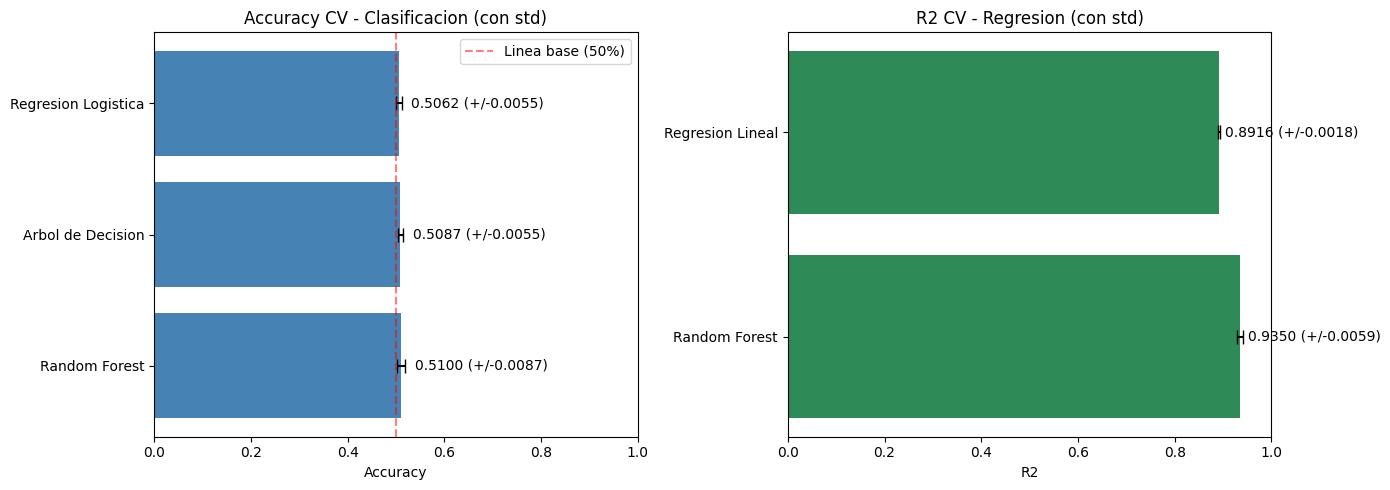

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clasificacion - Accuracy con std
nombres_clf = cv_clf['Modelo'].tolist()
acc_clf = cv_clf['Accuracy Media'].tolist()
std_clf = cv_clf['Desviacion Std'].tolist()
axes[0].barh(nombres_clf, acc_clf, xerr=std_clf, color='steelblue', capsize=5)
axes[0].set_title('Accuracy CV - Clasificacion (con std)')
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0, 1)
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Linea base (50%)')
axes[0].legend()
for i, (v, s) in enumerate(zip(acc_clf, std_clf)):
    axes[0].text(v + s + 0.02, i, f'{v:.4f} (+/-{s:.4f})', va='center')

# Regresion - R2 con std
nombres_reg = cv_reg['Modelo'].tolist()
r2 = cv_reg['R2 Medio'].tolist()
std_r2 = cv_reg['Desviacion Std R2'].tolist()
axes[1].barh(nombres_reg, r2, xerr=std_r2, color='seagreen', capsize=5)
axes[1].set_title('R2 CV - Regresion (con std)')
axes[1].set_xlabel('R2')
axes[1].set_xlim(0, 1)
for i, (v, s) in enumerate(zip(r2, std_r2)):
    axes[1].text(v + s + 0.01, i, f'{v:.4f} (+/-{s:.4f})', va='center')

plt.tight_layout()
plt.show()

## 7. Analisis del Problema de Clasificacion

**Por que la clasificacion no funciona?**

Despues de probar 3 algoritmos distintos (uno simple, uno robusto y uno lineal), ninguno supera el 51% de accuracy. Esto es practicamente el equivalente a tirar una moneda.

Las razones que vemos son:

1. **Falta de relacion entre features y target.** Las variables disponibles (`Category`, `Item`, `Price Per Unit`, `Quantity`, `Total Spent`, `Payment Method`, `Location`, `Timestamp`) no contienen informacion suficiente para predecir si una transaccion tuvo o no descuento aplicado.
2. **Posible aleatoriedad del descuento en el dataset.** Si los descuentos se aplicaron de forma aleatoria o por reglas de negocio que no estan representadas en los datos (por ejemplo, cupones individuales, promociones de un dia), no hay patron que aprender.

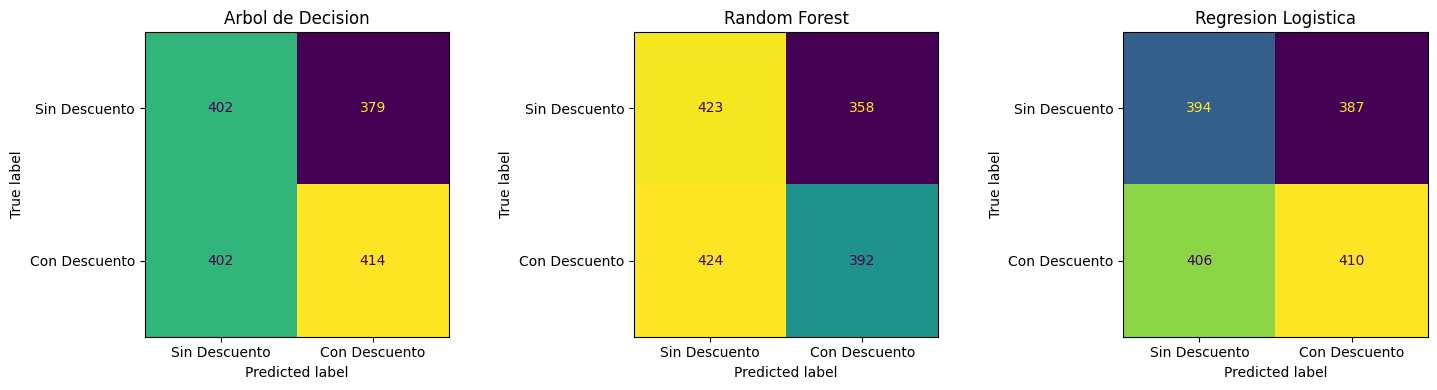

In [10]:
# Matrices de confusion finales - clasificacion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, y_pred) in zip(axes, [
    ('Arbol de Decision', y_pred_arbol),
    ('Random Forest', y_pred_rf_clf),
    ('Regresion Logistica', y_pred_lr_clf)
]):
    cm = confusion_matrix(y_test_clf, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin Descuento', 'Con Descuento'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

Como podemos ver, las matrices de confusion estan **balanceadas en errores y aciertos** (no hay clase dominante), lo que confirma que el modelo no esta sesgado: simplemente no logra discriminar.

## 8. Conclusiones Finales

**Sobre el dataset:**

- Empezamos con **12.575 transacciones** y terminamos con **7.983 filas limpias** despues de descartar nulos irrecuperables (especialmente `Discount Applied`).
- El pipeline de recuperacion permitio rescatar **609 precios unitarios** (formula directa) e **609 items** (mapeo Category + Price Per Unit), lo que evito perder mas datos.

**Sobre clasificacion (`Discount Applied`):**

- Los 3 modelos quedaron cerca del **51% de accuracy**, equivalente a azar.
- La validacion cruzada confirma que no es un problema de varianza ni de overfitting: el target simplemente **no es predecible** con las features disponibles.
- Este es un **hallazgo valido del analisis**: no todos los problemas son resolubles con los datos que tenemos.

**Sobre regresion (`Total Spent`):**

- Random Forest supera claramente a Regresion Lineal (**R2 0.94 vs 0.89** en CV).
- El modelo es estable: la desviacion estandar de R2 entre folds es menor a 0.01.

## 9. Recomendaciones y Trabajo Futuro

1. **Hiperparametros (notebook 04):** El compañero esta optimizando hiperparametros en otra rama con `GridSearchCV` y `RandomizedSearchCV`. Eso debiera empujar el R2 de Random Forest un poco mas arriba.

2. **Aprendizaje no supervisado:** Aplicar clustering (KMeans) y reduccion de dimensionalidad (PCA) sobre los clientes para detectar segmentos de comportamiento. Las librerias ya estan importadas en el notebook 01, falta el desarrollo.

3. **Para el problema de clasificacion no predecible:**
   - Buscar nuevas features: dia de la semana, mes, hora, frecuencia historica del cliente.
   - Conseguir el contexto de negocio: que reglas se usaron para aplicar descuentos.
   - Reformular el problema como deteccion de anomalias en lugar de clasificacion binaria.

4. **Para regresion:**
   - Probar Gradient Boosting (XGBoost, LightGBM) — suelen superar a Random Forest en datos tabulares.
   - Evaluar si la relacion `Total Spent = Quantity * Price Per Unit` esta filtrando informacion al modelo (data leakage).

5. **Reproducibilidad:** Serializar los modelos finales con `joblib` en `models/trained_models/` para no tener que reentrenar.